In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [5]:
gold_data = pd.read_csv('/content/gld_price_data.csv')
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [6]:
gold_data.shape

(2290, 6)

In [7]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [8]:
X = gold_data.drop(columns='EUR/USD', axis=1)

In [9]:
print(X.shape)

(2290, 5)


In [10]:
Y = gold_data['EUR/USD']
Y.shape

(2290,)

In [11]:
Y.head()

,EUR/USD
0,1.471692
1,1.474491
2,1.475492
3,1.468299
4,1.557099


In [12]:
print(X.shape, Y.shape)

(2290, 5) (2290,)


In [13]:
gold_data['EUR/USD'].value_counts()

,count
EUR/USD,
1.437298,4
1.307019,3
1.296496,3
1.319087,3
1.578507,3
...,...
1.449695,1
1.435791,1
1.431680,1


In [14]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [15]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [16]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [17]:
corrolation = gold_data.drop(columns='Date', axis=1).corr()

<Axes: >

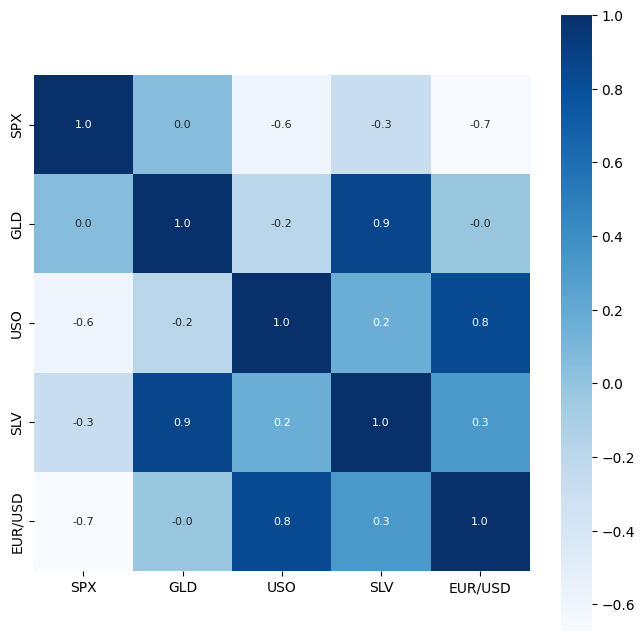

In [18]:
plt.figure(figsize=(8,8))
sns.heatmap(corrolation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [19]:
print(corrolation.GLD)

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


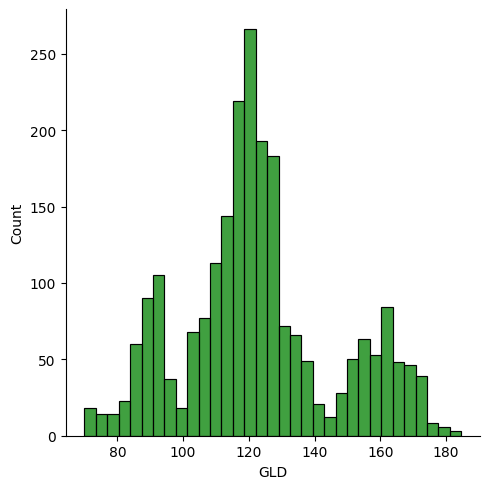

In [20]:
sns.displot(gold_data.GLD, color='green')

In [21]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [23]:
X = gold_data.drop(['Date','GLD'], axis = 1)
X.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [27]:

Y = gold_data['GLD']
Y.head()

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999


In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [31]:
regressor = RandomForestRegressor(n_estimators=100)

In [32]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [34]:
test_data_prediction = regressor.predict(X_test)


In [35]:
print(test_data_prediction)

[168.46279941  81.95369985 115.74160017 127.69000055 120.81590155
 154.93849711 150.38519803 126.16830024 117.41449898 126.04200077
 116.61820092 170.46960112 142.1854993  168.06039886 115.19729985
 117.60390059 140.3278029  170.20330142 159.09220341 159.18409876
 155.09790048 125.57710048 175.72779995 157.38000367 125.17890034
  93.92029981  77.98700001 120.85600005 119.18589977 167.48120028
  88.11140039 125.31050002  91.30090057 117.61190029 121.11649917
 136.30960012 115.40410132 115.39610047 148.04760056 107.3340012
 104.50940227  87.34329816 126.41540063 117.88550013 151.47419877
 119.5481001  108.51579987 108.11819828  93.28260039 127.14029743
  75.02730016 113.65559911 121.47830001 111.27119886 118.94819907
 120.70579937 160.30429954 167.83980055 147.12419706  85.83689844
  94.13750029  86.80829892  90.74589995 119.01210073 126.51650052
 127.62800017 168.97719954 122.20589967 117.4976992   98.78060003
 168.36850118 143.18189902 132.13950284 121.18100243 120.50679977
 119.821500

In [36]:
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("error_score", error_score)

error_score 0.9887977574738118


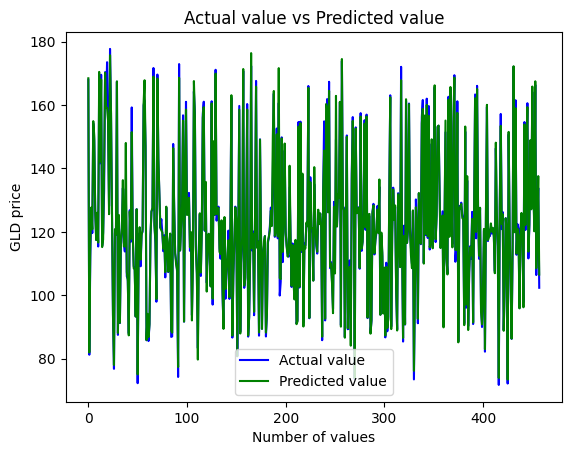

In [39]:
Y_test = list(Y_test)
plt.plot(Y_test, color='blue', label = 'Actual value')
plt.plot(test_data_prediction, color='green', label='Predicted value')
plt.title("Actual value vs Predicted value")
plt.xlabel('Number of values')
plt.ylabel('GLD price')
plt.legend()
plt.show()